Import Libraries

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (10,6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

COLORS = {
    "Best Customer": "#27AE60",
    "Loyal Customer": "#2980B9",
    "Big Spender": "#F1C40F",
    "Regular": "#7F8C8D"
}

Load & Extract Data

In [72]:
def extract_zip(zip_path, extract_path="/content/data"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    return extract_path


def load_csv(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            return pd.read_csv(os.path.join(folder_path, file), encoding='ISO-8859-1')

Data Cleaning

In [73]:
def clean_data(df):
    df = df.dropna(subset=['CustomerID'])
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    return df

Feature Engineering

In [74]:
def add_features(df):
    df['Revenue'] = df['Quantity'] * df['UnitPrice']
    return df


def create_rfm(df):
    snapshot_date = df['InvoiceDate'].max()

    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'Revenue': 'sum'
    })

    rfm.columns = ['Recency', 'Frequency', 'Monetary']
    return rfm

RFM Scoring

In [75]:
def rfm_scoring(rfm):
    rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
    rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
    rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

    rfm['RFM_Score'] = rfm[['R','F','M']].astype(str).sum(axis=1)
    return rfm

Segmentation

In [76]:
def segment_customer(rfm):
    def segment(row):
        if row['RFM_Score'] == '444':
            return 'Best Customer'
        elif row['F'] == 4:
            return 'Loyal Customer'
        elif row['M'] == 4:
            return 'Big Spender'
        else:
            return 'Regular'

    rfm['Segment'] = rfm.apply(segment, axis=1)
    return rfm

Visualization

/tmp/ipykernel_1534/2548255929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


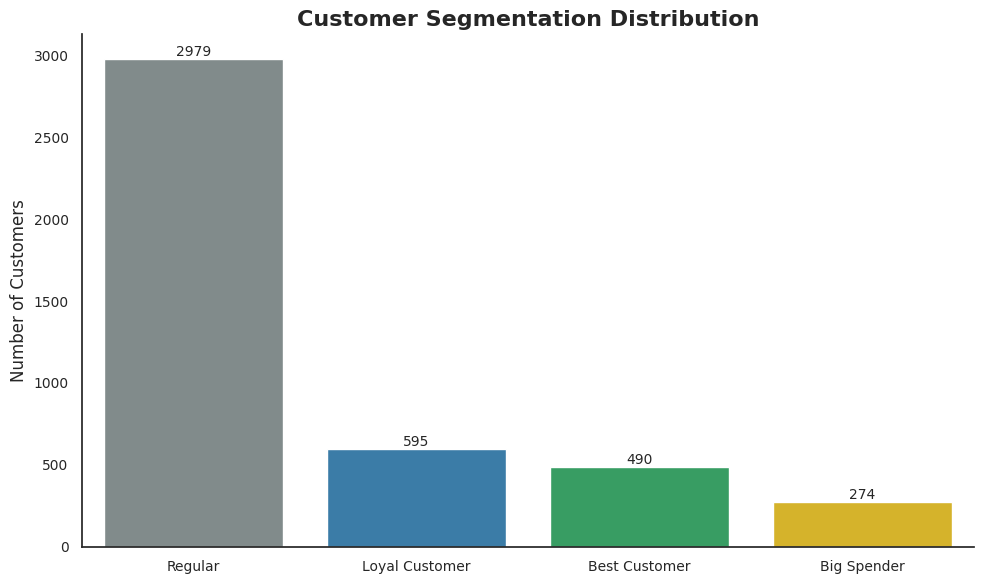

In [77]:
plt.figure()

ax = sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index,
    palette=COLORS
)

# title & label
plt.title("Customer Segmentation Distribution", weight='bold')
plt.xlabel("")
plt.ylabel("Number of Customers")

# remove top/right border
sns.despine()

# add value label
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [78]:
def plot_revenue_distribution(rfm):
    plt.figure()
    sns.histplot(rfm['Monetary'], bins=50, kde=True, color='#3498DB')
    plt.xscale('log')
    plt.title("Revenue Distribution (Log Scale)", weight='bold')
    plt.xlabel("Revenue (log scale)")
    plt.show()

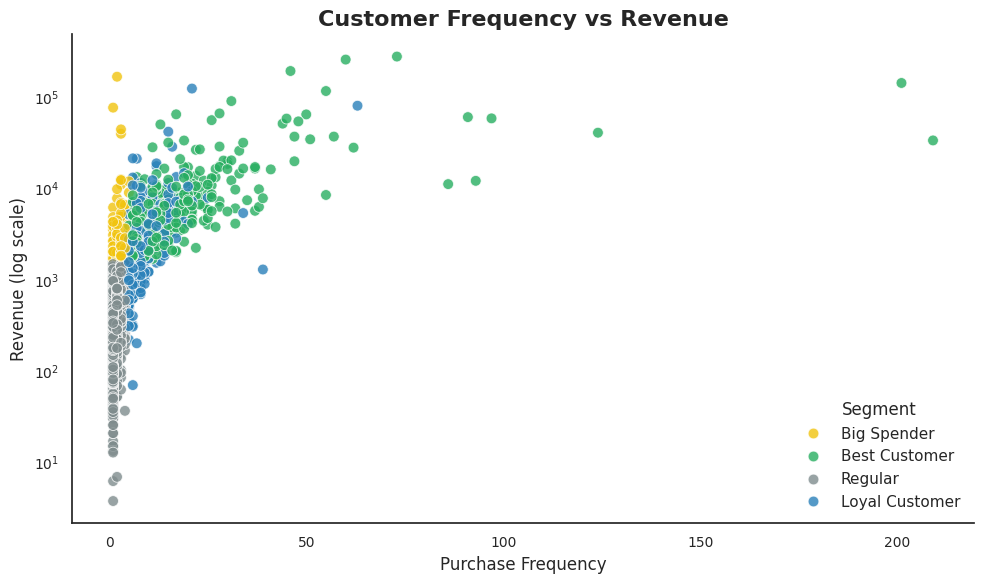

In [79]:
plt.figure()

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette=COLORS,
    alpha=0.8,
    s=60
)

plt.yscale("log")

plt.title("Customer Frequency vs Revenue", weight='bold')
plt.xlabel("Purchase Frequency")
plt.ylabel("Revenue (log scale)")

sns.despine()
plt.legend(title="Segment", frameon=False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1534/2879108215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


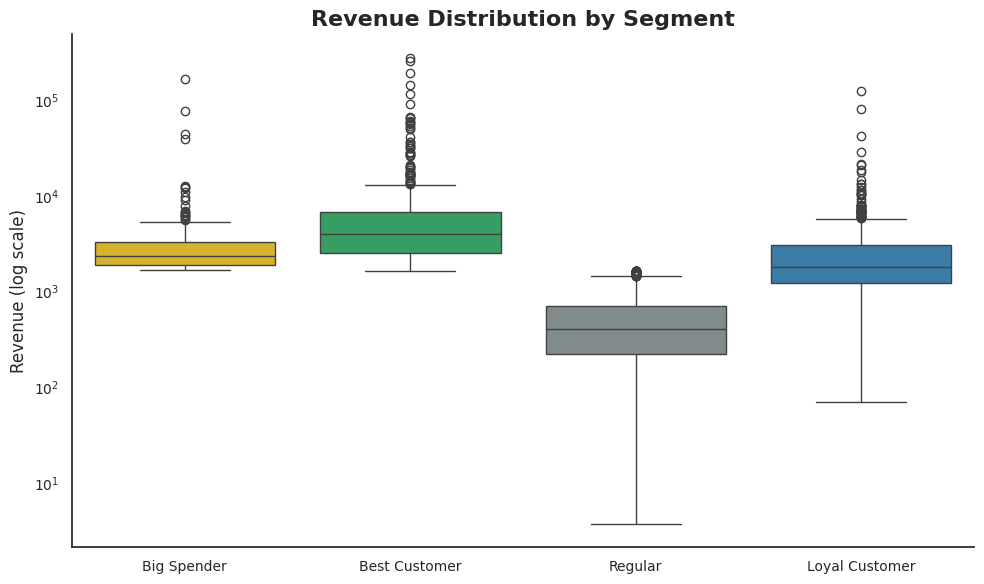

In [85]:
plt.figure()

sns.boxplot(
    data=rfm,
    x="Segment",
    y="Monetary",
    palette=COLORS
)

plt.yscale("log")

plt.title("Revenue Distribution by Segment", weight='bold')
plt.xlabel("")
plt.ylabel("Revenue (log scale)")

sns.despine()
plt.tight_layout()

plt.show()

In [81]:
def plot_heatmap(rfm):
    plt.figure()
    corr = rfm[['Recency','Frequency','Monetary']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("RFM Correlation Matrix", weight='bold')
    plt.show()

In [82]:
def plot_pie(rfm):
    plt.figure()
    rfm['Segment'].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=COLOR_PALETTE.values(),
        startangle=140
    )
    plt.title("Customer Segment Proportion", weight='bold')
    plt.ylabel("")
    plt.show()

Pipeline Execution

In [83]:
data_path = extract_zip("/content/archive (3).zip")
df = load_csv(data_path)

df = clean_data(df)
df = add_features(df)

rfm = create_rfm(df)
rfm = rfm_scoring(rfm)
rfm = segment_customer(rfm)

Plots

/tmp/ipykernel_1534/2826830154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


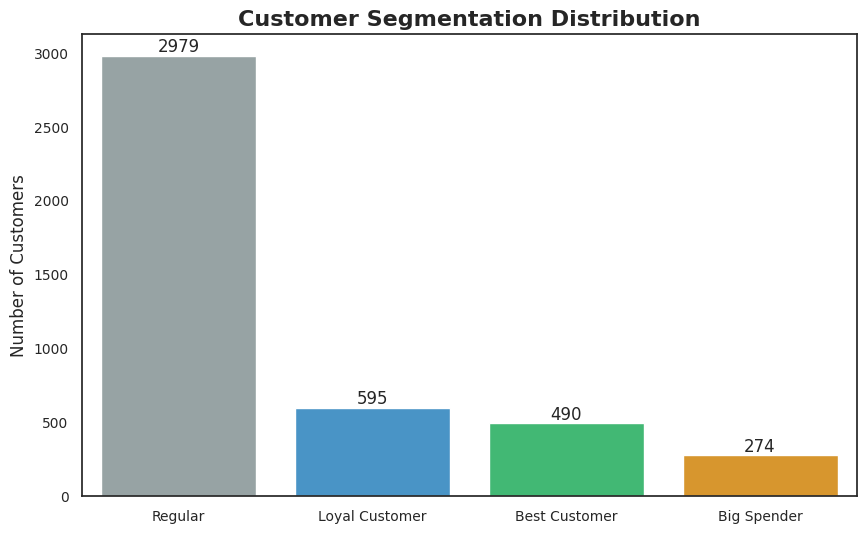

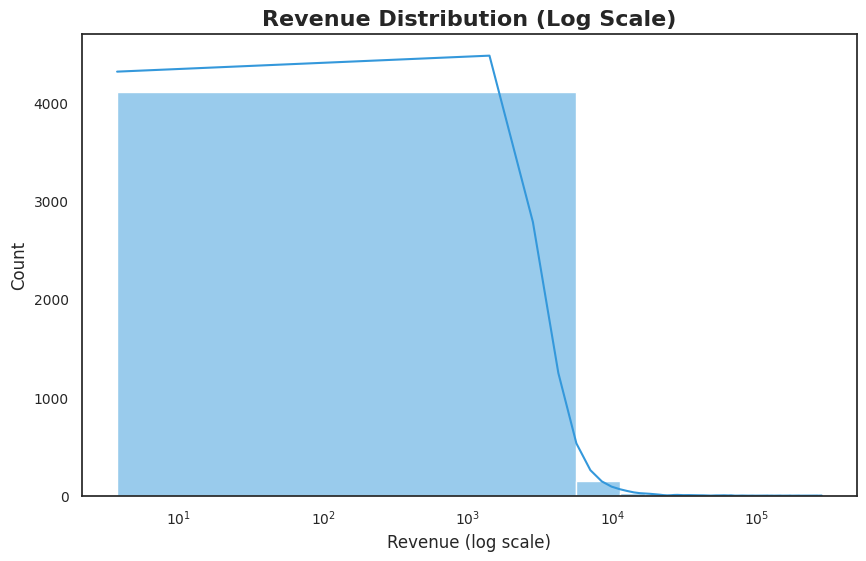

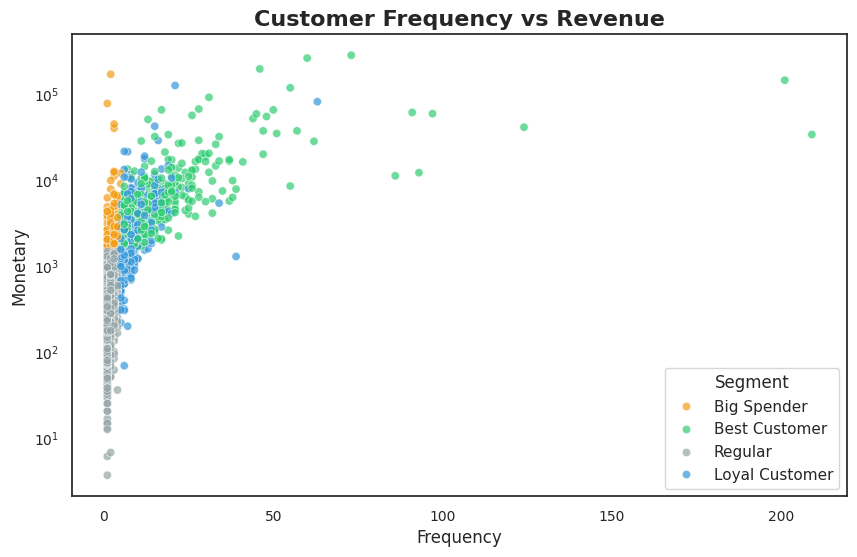

/tmp/ipykernel_1534/24089791.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


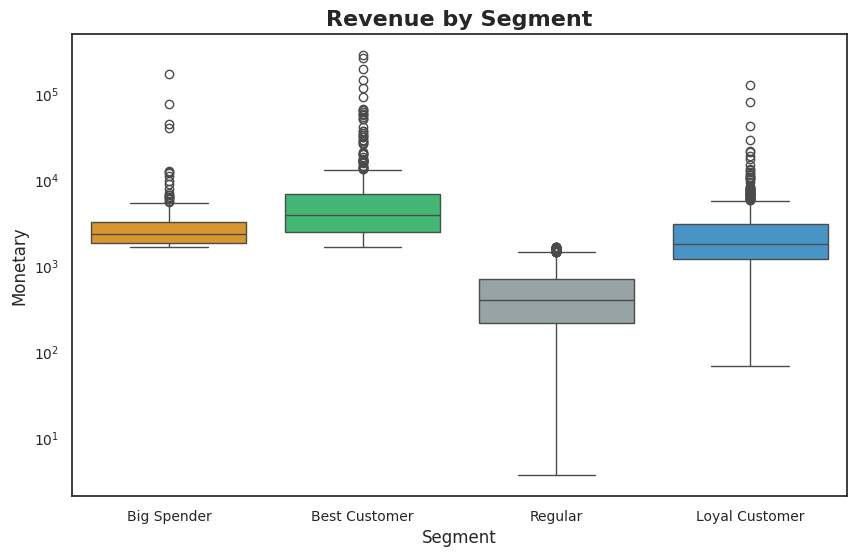

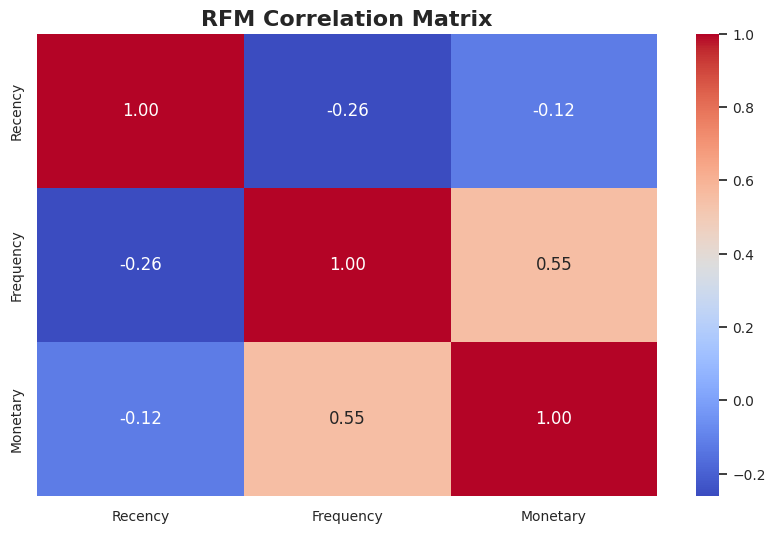

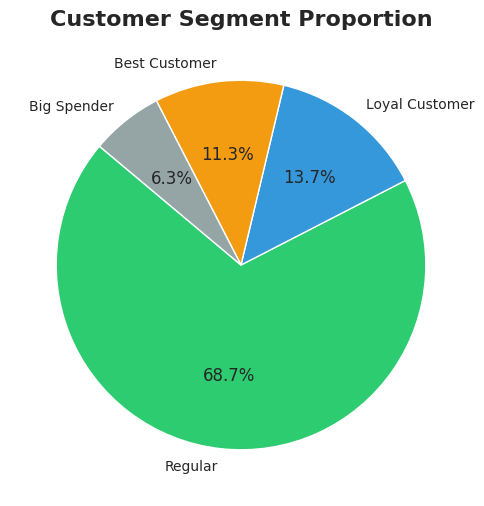

In [84]:
plot_segment_bar(rfm)
plot_revenue_distribution(rfm)
plot_scatter(rfm)
plot_boxplot(rfm)
plot_heatmap(rfm)
plot_pie(rfm)